In [12]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import kagglehub

In [13]:

dataset_path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print(f"Dataset downloaded to: {dataset_path}")


base_dir = dataset_path
train_data_dir = os.path.join(base_dir, 'asl_alphabet_train', 'asl_alphabet_train')
test_data_dir = os.path.join(base_dir, 'asl_alphabet_test', 'asl_alphabet_test')

if not os.path.exists(train_data_dir):
    possible_train_dirs = [
        os.path.join(base_dir, 'asl_alphabet_train'),
        os.path.join(base_dir, 'train'),
        base_dir
    ]
    for p_dir in possible_train_dirs:
        if os.path.exists(p_dir) and any(os.path.isdir(os.path.join(p_dir, d)) for d in os.listdir(p_dir) if not d.startswith('.')):
            train_data_dir = p_dir
            break

if not os.path.exists(test_data_dir):
    possible_test_dirs = [
        os.path.join(base_dir, 'asl_alphabet_test'),
        os.path.join(base_dir, 'test'),
    ]
    for p_dir in possible_test_dirs:
        if os.path.exists(p_dir):
            test_data_dir = p_dir
            break

print(f"Training data directory: {train_data_dir}")
print(f"Test data directory: {test_data_dir}")

img_width, img_height = 200, 200
batch_size = 32
num_classes = 29  

class_labels = sorted([d for d in os.listdir(train_data_dir) if os.path.isdir(os.path.join(train_data_dir, d))])
num_classes_actual = len(class_labels)
print(f"Detected {num_classes_actual} classes: {class_labels[:10]}...") 

if num_classes_actual != num_classes:
    print(f"Warning: Expected {num_classes} classes, but found {num_classes_actual}. Adjusting num_classes.")
    num_classes = num_classes_actual

Dataset downloaded to: C:\Users\benin\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1
Training data directory: C:\Users\benin\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_train\asl_alphabet_train
Test data directory: C:\Users\benin\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_test\asl_alphabet_test
Detected 29 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']...


In [14]:
# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False, # Usually not good for sign language
    validation_split=0.2  # Use 20% of training data for validation
)

# Only rescaling for Test/Validation
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    classes=class_labels
)

validation_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    classes=class_labels
)

# Check if a separate test directory exists and has images
test_images = []
if os.path.exists(test_data_dir):
    test_images = [f for f in os.listdir(test_data_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if test_images:
    print(f"Found {len(test_images)} images in test directory for manual evaluation.")
    # You can create a generator for test images if they are organized in subdirectories by class
    # For now, we'll just use the validation split for evaluation
else:
    print("No separate test directory found with labeled images. Using validation split for evaluation.")

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Found 28 images in test directory for manual evaluation.


In [15]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')  # Output layer for 29 classes
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

C:\Users\benin\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,809,821 (25.98 MB)

 Trainable params: 6,809,821 (25.98 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

# Calculate steps per epoch
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1577s 723ms/step - accuracy: 0.8207 - loss: 0.5271 - val_accuracy: 0.7179 - val_loss: 0.9073 - learning_rate: 0.0010
Epoch 2/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1578s 726ms/step - accuracy: 0.9120 - loss: 0.2615 - val_accuracy: 0.7922 - val_loss: 0.7467 - learning_rate: 0.0010
Epoch 3/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2196s 1s/step - accuracy: 0.9404 - loss: 0.1823 - val_accuracy: 0.8183 - val_loss: 0.6039 - learning_rate: 0.0010
Epoch 4/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2400s 1s/step - accuracy: 0.9518 - loss: 0.1435 - val_accuracy: 0.8002 - val_loss: 0.6766 - learning_rate: 0.0010
Epoch 5/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2308s 1s/step - accuracy: 0.9579 - loss: 0.1241 - val_accuracy: 0.8193 - val_loss: 0.7369 - learning_rate: 0.0010
Epoch 6/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2374s 1s/step - accuracy: 0.9645 - loss: 0.1097 - val_accuracy: 0.8363 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 7/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 2378s 1s/step - 

544/544 ━━━━━━━━━━━━━━━━━━━━ 195s 357ms/step - accuracy: 0.8600 - loss: 0.5708

Validation Accuracy: 0.8641


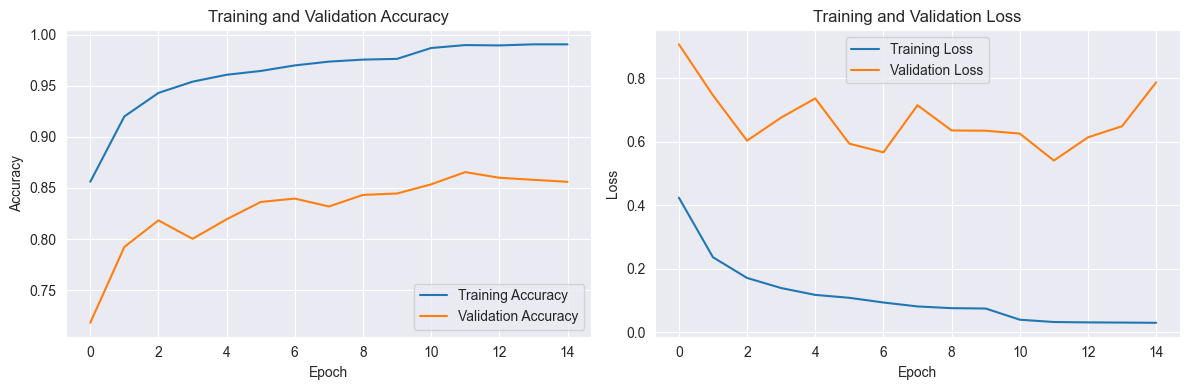

In [18]:
# Evaluate on validation data
val_loss, val_acc = model.evaluate(validation_generator)
print(f"\nValidation Accuracy: {val_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

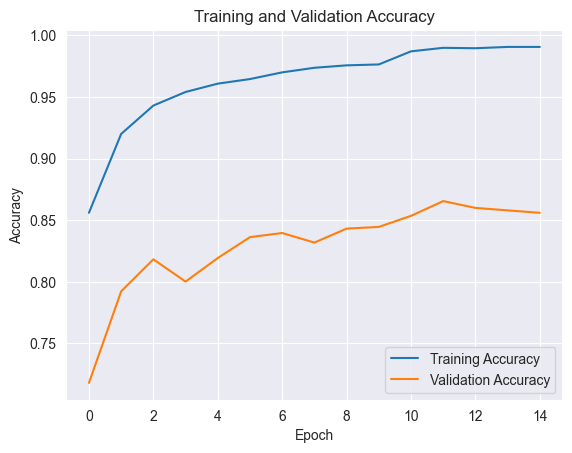

In [25]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

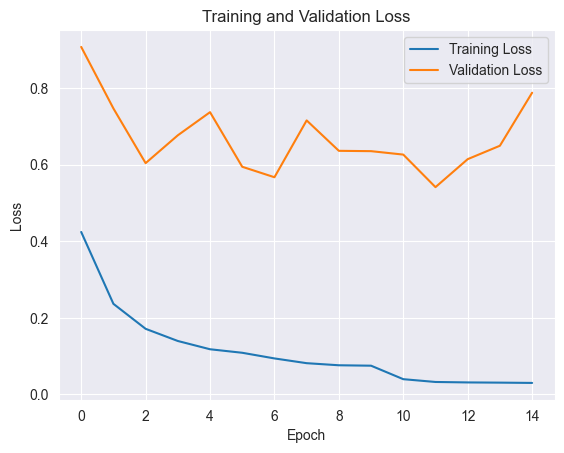

In [26]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

544/544 ━━━━━━━━━━━━━━━━━━━━ 206s 376ms/step


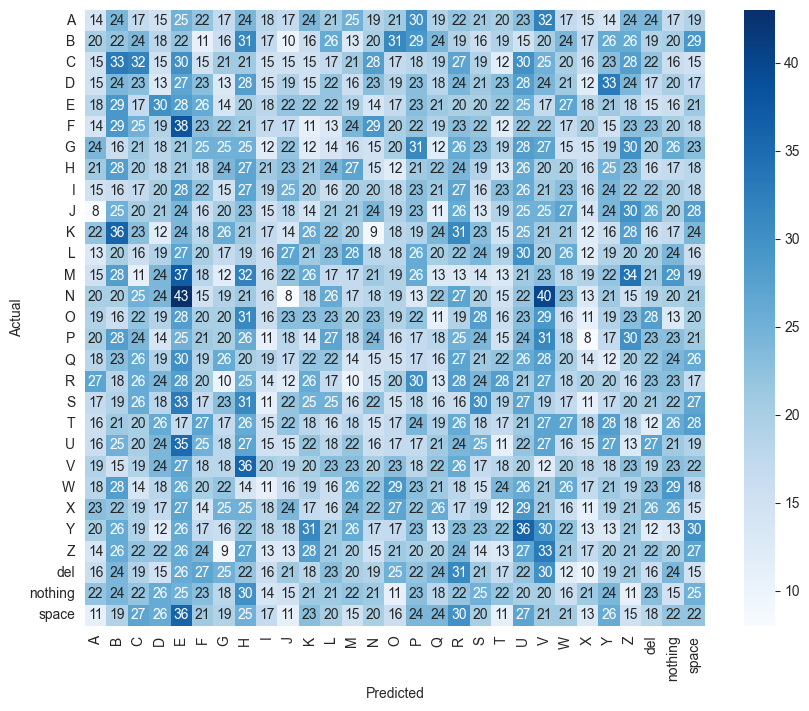

              precision    recall  f1-score   support

           A       0.03      0.02      0.03       600
           B       0.03      0.04      0.03       600
           C       0.05      0.05      0.05       600
           D       0.02      0.02      0.02       600
           E       0.03      0.05      0.04       600
           F       0.04      0.04      0.04       600
           G       0.05      0.04      0.04       600
           H       0.04      0.04      0.04       600
           I       0.04      0.03      0.04       600
           J       0.03      0.03      0.03       600
           K       0.04      0.04      0.04       600
           L       0.04      0.04      0.04       600
           M       0.03      0.03      0.03       600
           N       0.03      0.03      0.03       600
           O       0.03      0.03      0.03       600
           P       0.03      0.03      0.03       600
           Q       0.03      0.03      0.03       600
           R       0.04    

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# predict on validation set
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

# visualise
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()

# textual report
print(classification_report(y_true, y_pred_classes,
                            target_names=class_labels))

In [20]:
model_save_path = 'asl_alphabet_sequential_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to asl_alphabet_sequential_model.keras


Predicting class for: C:\Users\benin\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1\asl_alphabet_test\asl_alphabet_test\N_test.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Predicted class: N (Index: 13)


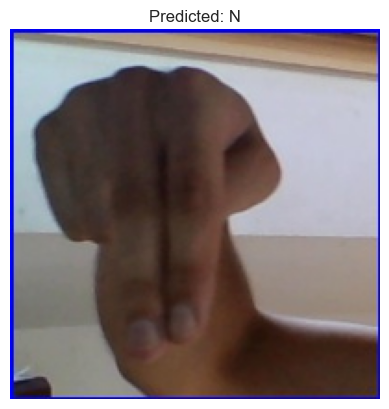

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np


if test_images:
    sample_test_image_path = os.path.join(test_data_dir, test_images[14])
    print(f"Predicting class for: {sample_test_image_path}")
    img = image.load_img(sample_test_image_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_labels[predicted_class_idx]

    print(f"Predicted class: {predicted_class} (Index: {predicted_class_idx})")
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
else:
    print("No test images found for prediction.")